# GlucoLens: Explainable ML for Early Prediction of Diabetes Risk

1. **Classification:** does a patient have diabetes? (Pima Indians Diabetes data)
2. **Regression:** how much will the disease progress in one year? (Diabetes Progression data)

| # | Rubric item | Marks | Section |
|---|---|---|---|
| 1 | Problem Understanding & Familiarization | 4 | A |
| 2 | Exploratory Data Analysis & Insights | 4 | B |
| 3 | Regression and Classification | 4 | C, D, E |
| 4 | Comparative Performance Analysis | 4 | F |
| 5 | Result Interpretation & Presentation | 4 | G, H |

## Setup
Import libraries, set one random seed for the whole notebook (so results are the same every run), and create folders for data and figures.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml, load_diabetes

RANDOM_STATE = 42  # used everywhere so results are reproducible

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Section A: Problem Understanding *(Rubric 1)*

## A.1 Background
- **Diabetes:** blood glucose stays too high because the body makes too little **insulin** or does not respond to it.
- **Type 1:** the body makes almost no insulin (autoimmune, usually starts young). **Type 2:** the body resists insulin; linked to obesity, inactivity and age. Most cases, and both our adult datasets, are Type 2.
- **Why early detection:** Type 2 can go unnoticed for years while damaging eyes, kidneys, nerves and heart. Catching it early lets lifestyle changes or treatment delay it.
- **Known risk factors:** high glucose, high BMI, older age, family history, high blood pressure.
- **Why explainability:** doctors must be able to see *why* a model flags a patient, to trust it, justify decisions and spot when the model is using a wrong signal.

## A.2 The two tasks

| | Classification | Regression |
|---|---|---|
| Data | Pima (768 patients, 8 features) | Progression (442 patients, 10 features) |
| Target | `Outcome`: 1 = diabetic, 0 = not | `target`: progression score after 1 year |
| Why this type | Target has only 2 values | Target is a continuous number |

- A classifier predicts a probability $\hat{p} = P(y=1 \mid \mathbf{x})$ and says "diabetic" if $\hat{p} \ge 0.5$ (we can change this threshold later).
- A regressor predicts a number $\hat{y} = f(\mathbf{x})$.

Here $\mathbf{x}$ = a patient's features, $y$ = the true target, $\hat{y}$ = the prediction.

## A.3 Feature dictionary

**Pima** (women aged 21+, Pima Indian heritage, Arizona)

| Feature | Unit | Meaning | Modifiable? |
|---|---|---|---|
| Pregnancies | count | Number of pregnancies | No |
| Glucose | mg/dL | Blood glucose 2 h after a sugar drink (glucose tolerance test) | Yes |
| BloodPressure | mm Hg | Diastolic blood pressure | Yes |
| SkinThickness | mm | Triceps skin-fold thickness (body fat) | Yes |
| Insulin | µU/mL | Blood insulin 2 h after the sugar drink | Partly |
| BMI | kg/m² | Weight / height² | Yes |
| DiabetesPedigreeFunction | score | Diabetes history in relatives (genetic risk) | No |
| Age | years | Age | No |
| **Outcome** | 0/1 | 1 = diabetic | target |

**Progression** (names as in scikit-learn)

| Feature | Meaning | Modifiable? |
|---|---|---|
| age | Age (years) | No |
| sex | Coded 1 or 2 (source does not say which is which) | No |
| bmi | Body mass index (kg/m²) | Yes |
| bp | Average blood pressure (mm Hg) | Yes |
| s1 | Total cholesterol | Yes |
| s2 | LDL ("bad" cholesterol) | Yes |
| s3 | HDL ("good" cholesterol) | Yes |
| s4 | Total cholesterol / HDL | Yes |
| s5 | Probably log of triglycerides | Yes |
| s6 | Blood sugar | Yes |
| **target** | Disease progression after 1 year (score) | target |

## A.4 Success criteria (set before seeing any results)

**Classification** (on the test set)
- **Recall ≥ 0.75**: catch at least 3 of every 4 diabetic patients. Missing a diabetic (false negative) is worse than a false alarm.
- **ROC-AUC ≥ 0.80**: the model ranks diabetic patients above non-diabetic ones well.

$$\text{Recall} = \frac{TP}{TP + FN}$$
($TP$ = diabetics correctly flagged, $FN$ = diabetics missed)

**Regression** (on the test set)
- Clearly beat a model that always predicts the mean (which has $R^2 = 0$); aim for **$R^2 \ge 0.40$**.

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
($y_i$ = true value, $\hat{y}_i$ = prediction, $\bar{y}$ = mean of true values)

## A.5 Load the data

**Pima:** download from OpenML the first time, rename the short column names (`preg`, `plas`, ...) to clear names, turn the text label into 1/0, and save to `data/pima.csv`. Later runs just read the CSV (works offline).

In [2]:
if os.path.exists("data/pima.csv"):
    pima = pd.read_csv("data/pima.csv")
else:
    pima = fetch_openml(name="diabetes", version=1, as_frame=True).frame
    pima.columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
    # label is text: "tested_positive" -> 1, "tested_negative" -> 0
    pima["Outcome"] = (pima["Outcome"] == "tested_positive").astype(int)
    pima.to_csv("data/pima.csv", index=False)

print("Pima shape:", pima.shape)
pima.head()

Pima shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Progression:** comes with scikit-learn. `scaled=False` keeps the real units (age in years, BMI in kg/m²) instead of pre-scaled numbers. Saved to `data/progression.csv`.

In [3]:
if os.path.exists("data/progression.csv"):
    prog = pd.read_csv("data/progression.csv")
else:
    prog = load_diabetes(as_frame=True, scaled=False).frame
    prog.to_csv("data/progression.csv", index=False)

print("Progression shape:", prog.shape)
prog.head()

Progression shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


**Observation:** Pima has **768 rows × 9 columns** (8 features + `Outcome`) and Progression has **442 rows × 11 columns** (10 features + `target`). Already in the first five Pima rows, `Insulin` is 0 for three patients and `SkinThickness` is 0 for one. These values are impossible, so they must be missing. The Progression values are in real units (e.g. age 59, BMI 32.1), so `scaled=False` worked.

## A.6 Data types and summary statistics

`.info()` shows each column's type and how many values are not missing. `.describe()` shows count, mean, standard deviation, min, quartiles (25%, 50% = **median**, 75%) and max.

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i \qquad s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$
($n$ = number of values, $\bar{x}$ = mean, $s$ = standard deviation)

In [4]:
pima.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
pima.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


**Observation:** `.info()` says all 768 values are present in every column, but `.describe()` shows a **minimum of 0** for Glucose, BloodPressure, SkinThickness, Insulin and BMI, which is impossible. The missing values are hidden as zeros. For SkinThickness and Insulin even the 25th percentile is 0, so at least a quarter of those values are missing. The mean of `Outcome` is 0.35, so about **35% of patients are diabetic**.

In [6]:
prog.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [7]:
prog.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,48.52,1.47,26.38,94.65,189.14,115.44,49.79,4.07,4.64,91.26,152.13
std,13.11,0.50,4.42,13.83,34.61,30.41,12.93,1.29,0.52,11.50,77.09
min,19.00,1.00,18.00,62.00,97.00,41.60,22.00,2.00,3.26,58.00,25.00
25%,38.25,1.00,23.20,84.00,164.25,96.05,40.25,3.00,4.28,83.25,87.00
50%,50.00,1.00,25.70,93.00,186.00,113.00,48.00,4.00,4.62,91.00,140.50
75%,59.00,2.00,29.28,105.00,209.75,134.50,57.75,5.00,5.00,98.00,211.50
max,79.00,2.00,42.20,133.00,301.00,242.40,99.00,9.09,6.11,124.00,346.00


**Observation:** There are no missing values (442 non-null in every column) and no impossible values. The `target` ranges from **25 to 346** (mean 152.13, std 77.09). The features are on very different scales (`s5` is around 4.6 while `s1` is around 189), so models based on distances or coefficients will need **scaling** (Section C).

## A.7 Limitations
- Pima has only adult women of one ethnic group, so results may not apply to others.
- Both datasets are small, so scores will vary between splits (we report cross-validation mean ± std).
- Diabetes is diagnosed from glucose, so a strong glucose effect is partly built into the label.
- Models find correlations, not causes. This is a course prototype, not a diagnostic tool.

# Section B: Exploratory Data Analysis *(Rubric 2)*

## B.1 Pima: hidden missing values

A value of `0` for Glucose, BloodPressure, SkinThickness, Insulin or BMI is impossible for a living person, so it means "not recorded". We count these zeros.

               zeros  percent
Glucose            5      0.7
BloodPressure     35      4.6
SkinThickness    227     29.6
Insulin          374     48.7
BMI               11      1.4


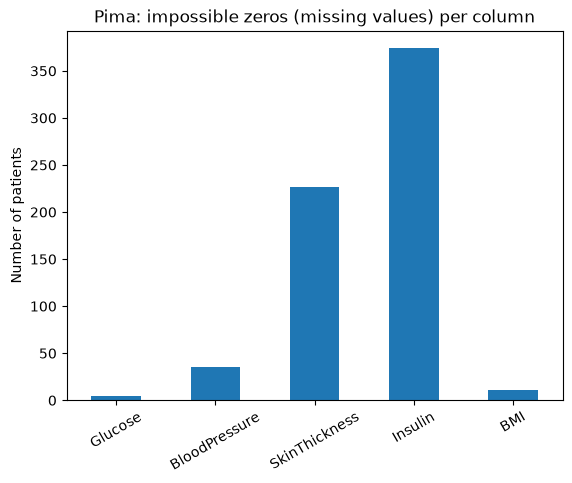

In [8]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (pima[zero_cols] == 0).sum()
zero_percent = (zero_counts / len(pima) * 100).round(1)
print(pd.DataFrame({"zeros": zero_counts, "percent": zero_percent}))

zero_counts.plot(kind="bar", color="tab:blue")
plt.title("Pima: impossible zeros (missing values) per column")
plt.ylabel("Number of patients")
plt.xticks(rotation=30)
plt.savefig("figures/fig01_pima_missing_zeros.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Missing values are concentrated in **Insulin (374 patients, 48.7%)** and **SkinThickness (227, 29.6%)**. BloodPressure (35), BMI (11) and Glucose (5) have only a few. If we treated these zeros as real numbers, they would drag the averages down and mislead the models, so we fill them with the median in Section C. Because almost half of the Insulin values will be filled in, any result involving Insulin should be read with caution.

We now replace these zeros with `NaN` (pandas' "missing" value), so the plots below show only real measurements.
This learns nothing from the data, so it causes no leakage. The missing values are **filled in later (Section C)** with the median of the training set only.

In [9]:
pima[zero_cols] = pima[zero_cols].replace(0, np.nan)
pima.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## B.2 Pima: class balance
How many patients are diabetic vs not?

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


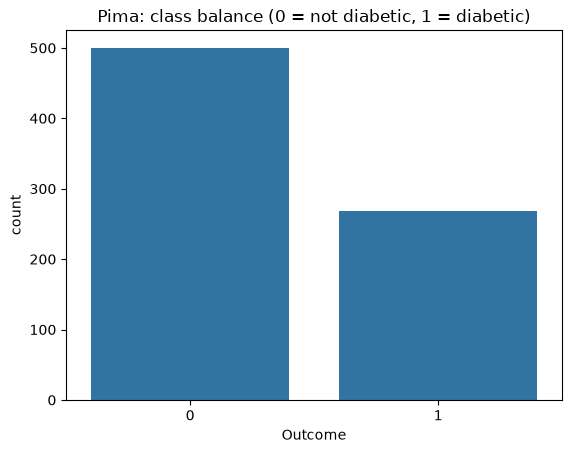

In [10]:
print(pima["Outcome"].value_counts())
print((pima["Outcome"].value_counts(normalize=True) * 100).round(1))

sns.countplot(x="Outcome", data=pima, color="tab:blue")
plt.title("Pima: class balance (0 = not diabetic, 1 = diabetic)")
plt.savefig("figures/fig02_pima_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** There are **500 non-diabetic (65.1%)** and **268 diabetic (34.9%)** patients. A useless model that always says "not diabetic" would already reach 65.1% accuracy, so accuracy is misleading here. This is why we use a stratified split, `class_weight="balanced"`, and recall as the main metric.

## B.3 Pima: feature distributions by Outcome
Histograms of each feature, coloured by class. Each class is scaled to the same area (`stat="density"`), because there are fewer diabetics and we want to compare **shapes**, not counts. If the two colours are shifted apart, that feature helps separate the classes.

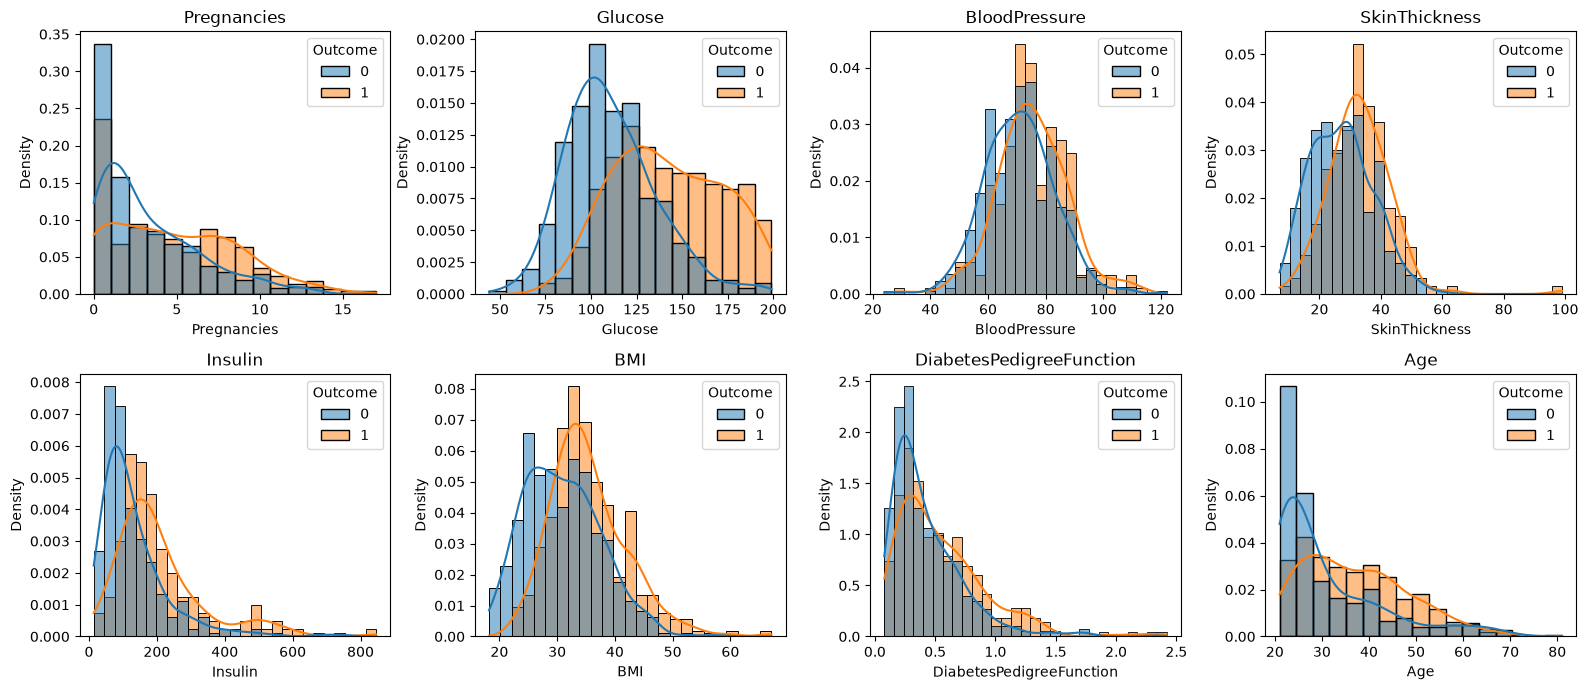

In [11]:
features = pima.columns.drop("Outcome")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), features):   # one small plot per feature
    sns.histplot(data=pima, x=col, hue="Outcome", kde=True, ax=ax,
                 stat="density", common_norm=False,  # compare shapes, not counts
                 palette=["tab:blue", "tab:orange"])
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/fig03_pima_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

To put numbers on the histograms, we compare the **median** of each feature in the two classes.

In [12]:
pima.groupby("Outcome").median().T

Outcome,0,1
Pregnancies,2.000,4.000
Glucose,107.000,140.000
BloodPressure,70.000,74.500
SkinThickness,27.000,32.000
Insulin,102.500,169.500
BMI,30.100,34.300
DiabetesPedigreeFunction,0.336,0.449
Age,27.000,36.000


**Observation:** **Glucose** shows the clearest shift: the median is 107 for non-diabetics and 140 for diabetics, and the diabetic curve sits clearly to the right. Diabetics also have higher medians for BMI (34.3 vs 30.1), Age (36 vs 27), Insulin (169.5 vs 102.5) and Pregnancies (4 vs 2). BloodPressure (74.5 vs 70) and DiabetesPedigreeFunction (0.449 vs 0.336) differ less, and their curves overlap a lot. Insulin, DiabetesPedigreeFunction, Age and Pregnancies are **right-skewed**: most values are small, with a long tail of large values.

## B.4 Pima: outliers

A box plot shows the median (middle line), the quartiles $Q_1$ and $Q_3$ (box edges) and dots for outliers. We use the **IQR rule**:

$$IQR = Q_3 - Q_1 \qquad \text{outlier if } x < Q_1 - 1.5\,IQR \ \text{ or } \ x > Q_3 + 1.5\,IQR$$

The small function below counts outliers per column with this rule. We use it for both datasets, so we write it once.

In [13]:
def count_outliers(df, columns):
    rows = []
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append([col, lower, upper, n])
    return pd.DataFrame(rows, columns=["feature", "lower", "upper", "n_outliers"])

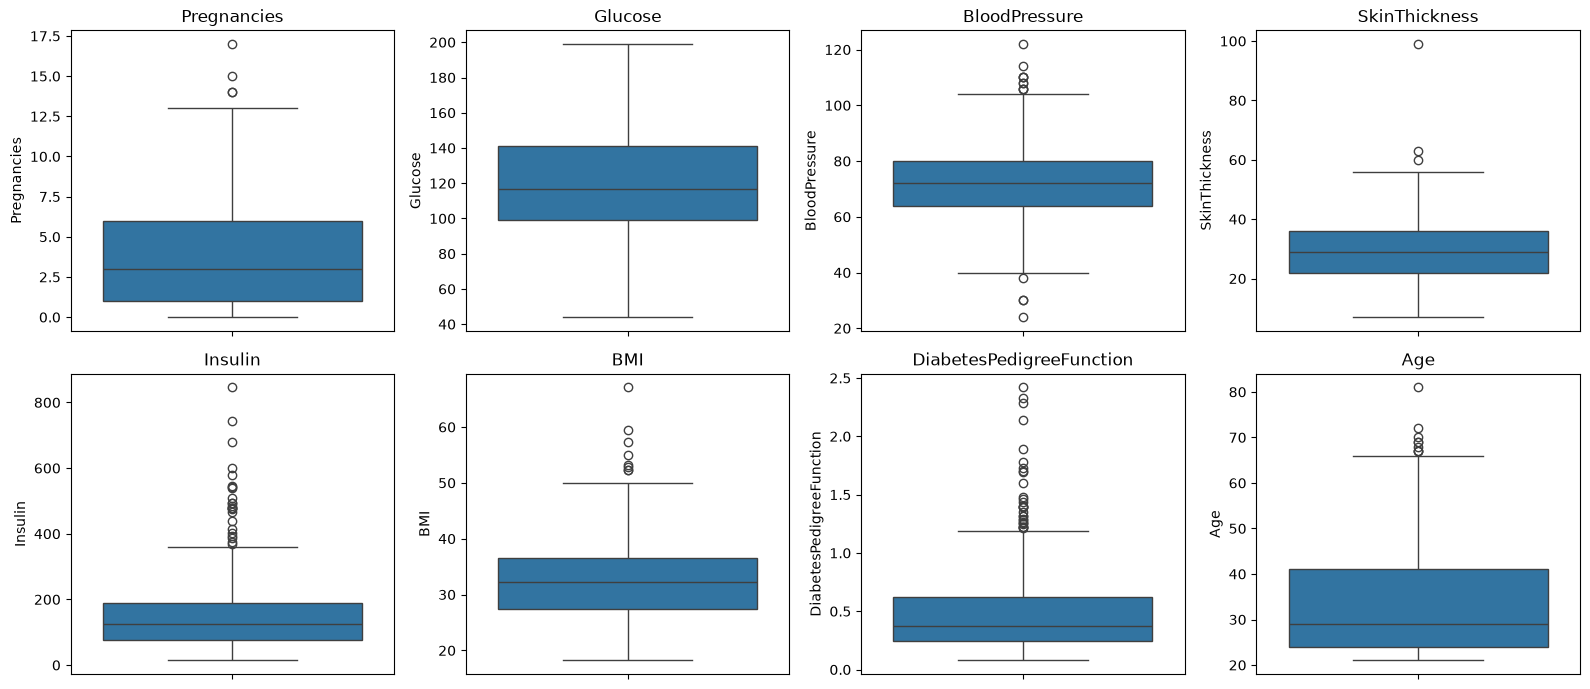

,feature,lower,upper,n_outliers
0,Pregnancies,-6.50,13.50,4
1,Glucose,36.00,204.00,0
2,BloodPressure,40.00,104.00,14
3,SkinThickness,1.00,57.00,3
4,Insulin,-94.38,360.62,24
5,BMI,13.85,50.25,8
6,DiabetesPedigreeFunction,-0.33,1.20,29
7,Age,-1.50,66.50,9


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(y=pima[col], ax=ax, color="tab:blue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/fig04_pima_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

count_outliers(pima, features).round(2)

**Observation:** The IQR rule flags the most outliers in DiabetesPedigreeFunction (29), Insulin (24) and BloodPressure (14), and **none in Glucose**. These look like real but extreme patients (for example, a few very high insulin readings), not data errors, so we **keep them**. Removing real patients would throw away information from an already small dataset.

## B.5 Pima: correlation

**Pearson correlation** $r$ measures how strongly two features rise or fall together in a straight line, from −1 to +1 (0 = no linear relation):

$$r = \frac{\text{cov}(X, Y)}{\sigma_X \, \sigma_Y}$$
($\text{cov}$ = covariance, $\sigma$ = standard deviation). Missing values are skipped pair by pair.

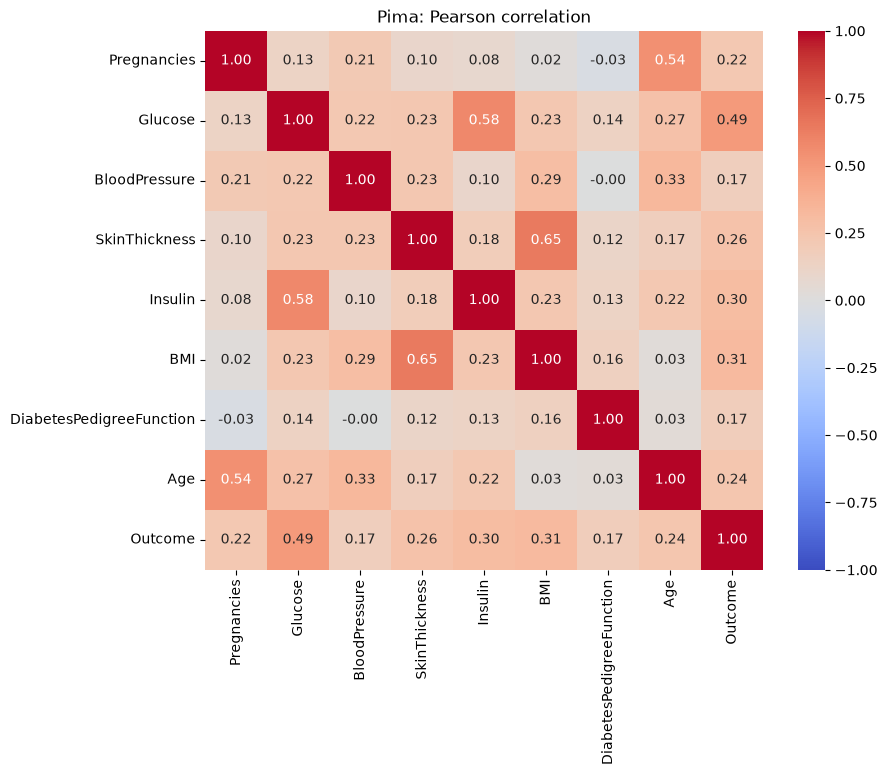

Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

In [15]:
pima_corr = pima.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(pima_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pima: Pearson correlation")
plt.savefig("figures/fig05_pima_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# correlation of each feature with the target, strongest first
pima_corr["Outcome"].drop("Outcome").sort_values(ascending=False)

**Observation:** **Glucose has the strongest correlation with Outcome (0.49)**, followed by BMI (0.31) and Insulin (0.30). BloodPressure and DiabetesPedigreeFunction are the weakest (0.17 each). Among the features themselves, the strongest pairs make clinical sense: SkinThickness–BMI (0.65, both measure body fat), Glucose–Insulin (0.58, the body releases insulin in response to glucose) and Age–Pregnancies (0.54). No pair is extremely high, so no feature is a near-duplicate of another.

## B.6 Pima: strongest relationships
Box plots of the three features most correlated with `Outcome`.

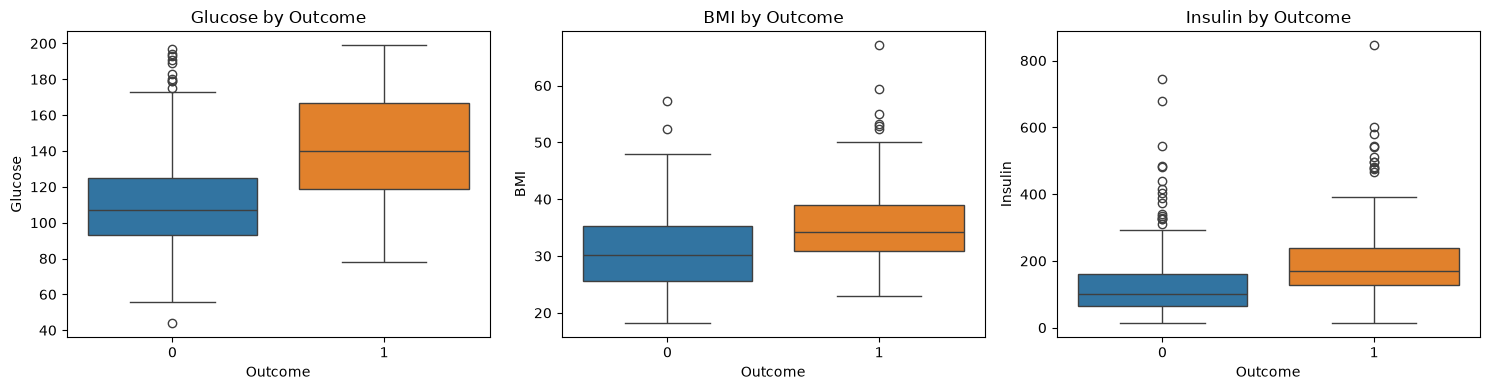

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Glucose", "BMI", "Insulin"]):
    sns.boxplot(data=pima, x="Outcome", y=col, ax=ax, hue="Outcome",
                palette=["tab:blue", "tab:orange"], legend=False)
    ax.set_title(col + " by Outcome")
plt.tight_layout()
plt.savefig("figures/fig06_pima_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** For all three features, the diabetic box (orange) sits higher. The gap is clearest for **Glucose**: the boxes holding the middle 50% of each class barely overlap. BMI and Insulin are higher for diabetics too, but their boxes overlap much more, so on their own they separate the classes less well.

## B.7 Progression: missing values and target distribution

Missing values in the whole table: 0


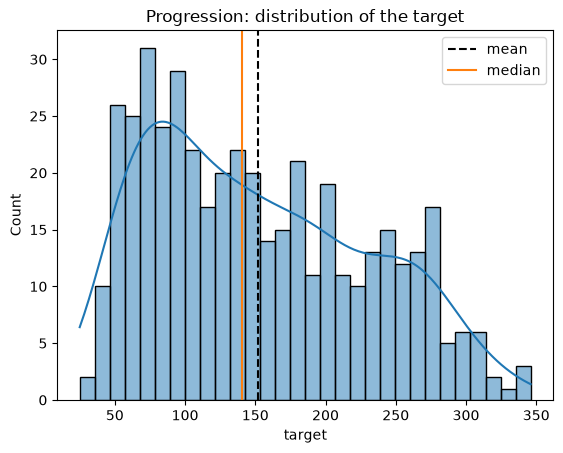

In [17]:
print("Missing values in the whole table:", prog.isnull().sum().sum())

sns.histplot(prog["target"], bins=30, kde=True, color="tab:blue")
plt.axvline(prog["target"].mean(), color="black", linestyle="--", label="mean")
plt.axvline(prog["target"].median(), color="tab:orange", label="median")
plt.legend()
plt.title("Progression: distribution of the target")
plt.savefig("figures/fig07_prog_target.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** There are **no missing values** in the progression data. The target is spread widely, from 25 to 346. The median (140.5) is lower than the mean (152.13), so the distribution is slightly right-skewed: more patients have low progression, with a tail of high values. The skew is mild, so we keep the target as it is.

## B.8 Progression: feature distributions

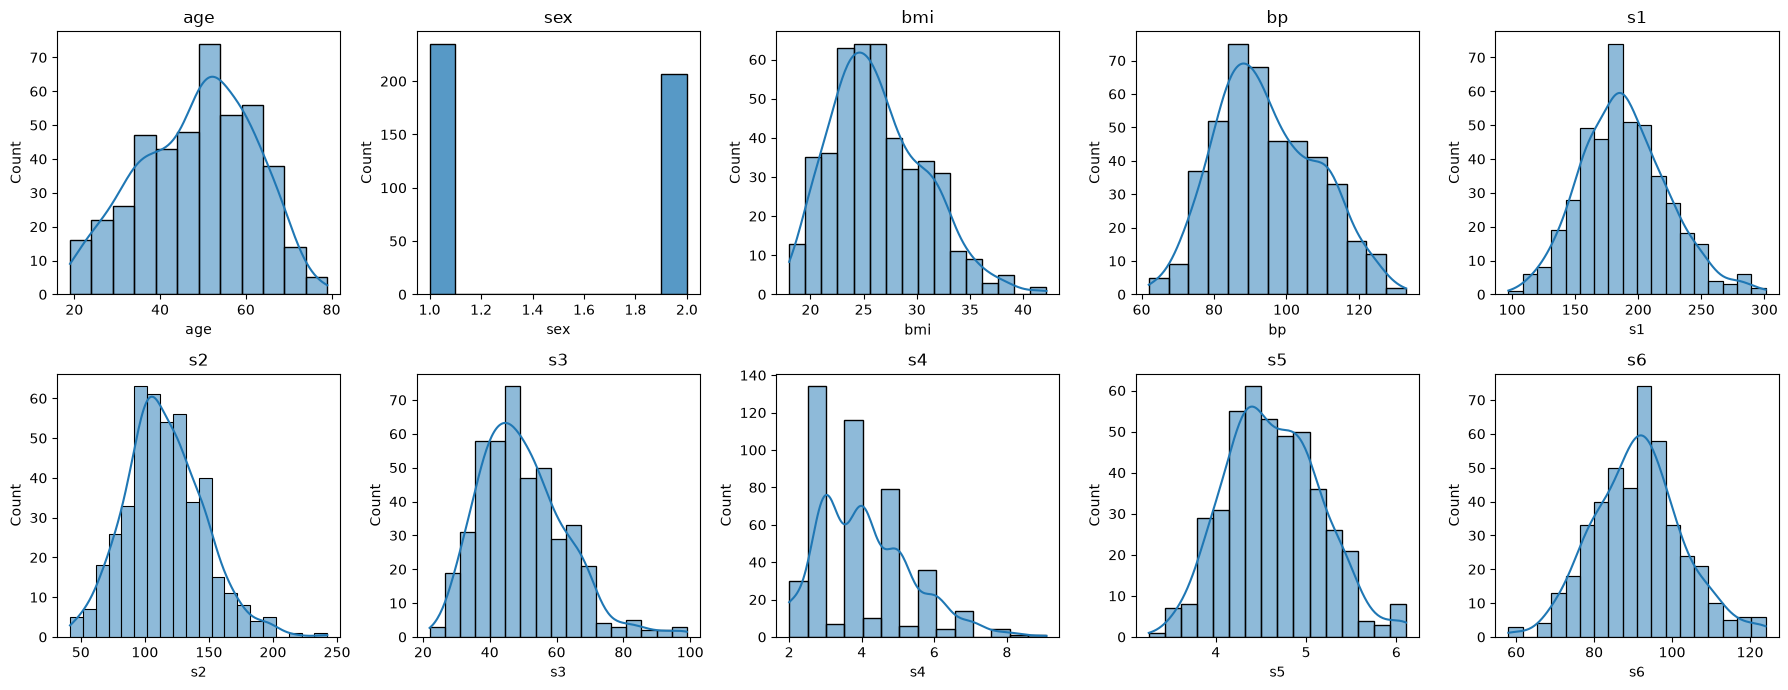

In [18]:
prog_features = prog.columns.drop("target")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flatten(), prog_features):
    # sex only has two values (1, 2), so a smooth KDE curve makes no sense there
    sns.histplot(prog[col], kde=(col != "sex"), ax=ax, color="tab:blue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/fig08_prog_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Most features are roughly bell-shaped, and `bmi` is slightly right-skewed. `sex` has only two values (235 patients coded 1, 207 coded 2). `s4` (total cholesterol / HDL) mostly takes whole numbers (3, 4, 5), which suggests it was rounded when recorded.

## B.9 Progression: outliers (same IQR rule)

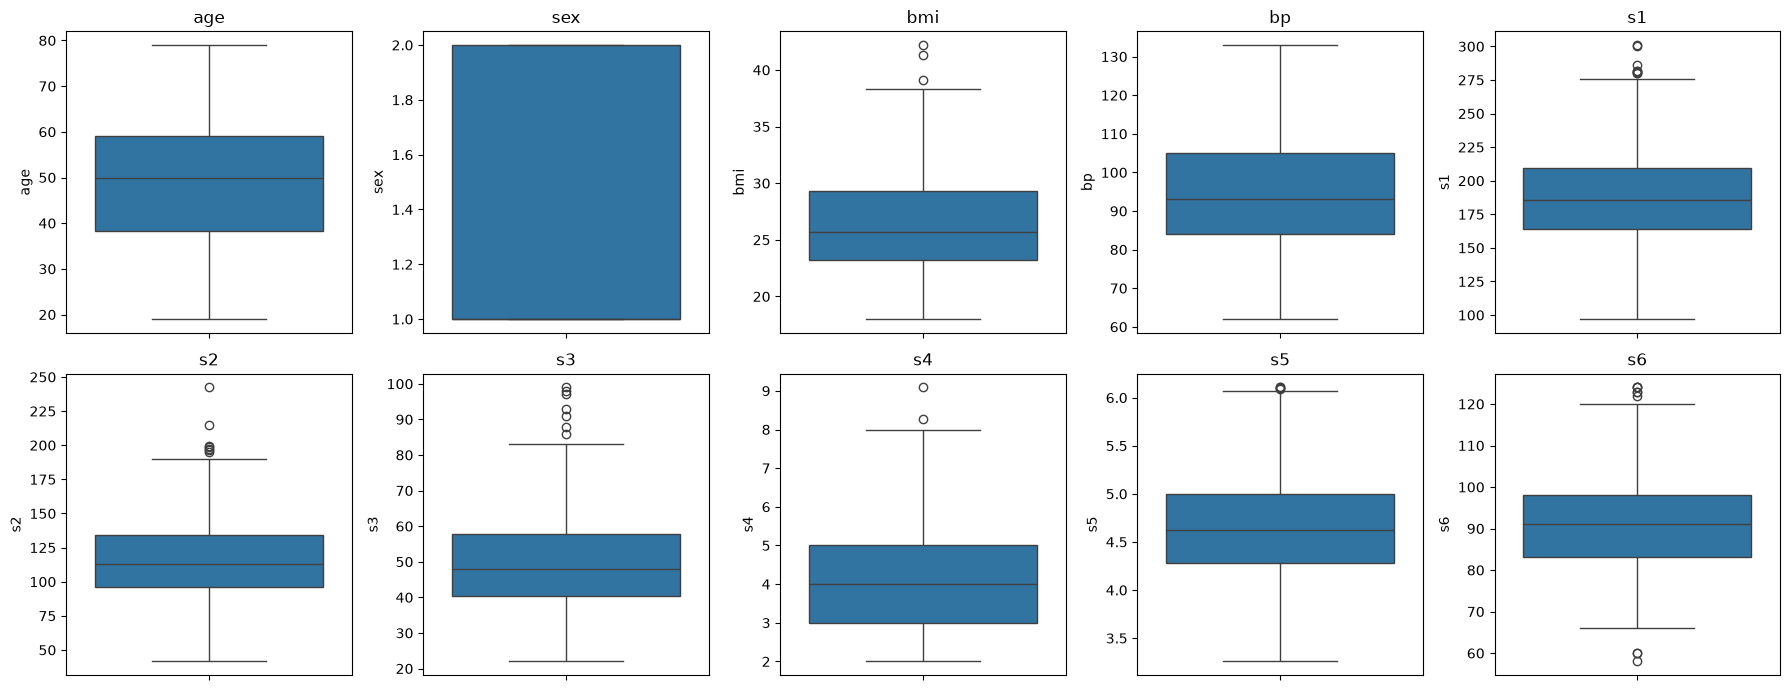

,feature,lower,upper,n_outliers
0,age,7.12,90.12,0
1,sex,-0.50,3.50,0
2,bmi,14.09,38.39,3
3,bp,52.50,136.50,0
4,s1,96.00,278.00,8
5,s2,38.37,192.18,7
6,s3,14.00,84.00,7
7,s4,0.00,8.00,2
8,s5,3.20,6.08,4
9,s6,61.12,120.12,9


In [19]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flatten(), prog_features):
    sns.boxplot(y=prog[col], ax=ax, color="tab:blue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figures/fig09_prog_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

count_outliers(prog, prog_features).round(2)

**Observation:** There are very few outliers: at most 9 in a column (`s6`), and none in `age`, `sex` or `bp`. With so few, and all of them plausible, we keep every patient.

## B.10 Progression: correlation (same Pearson formula)

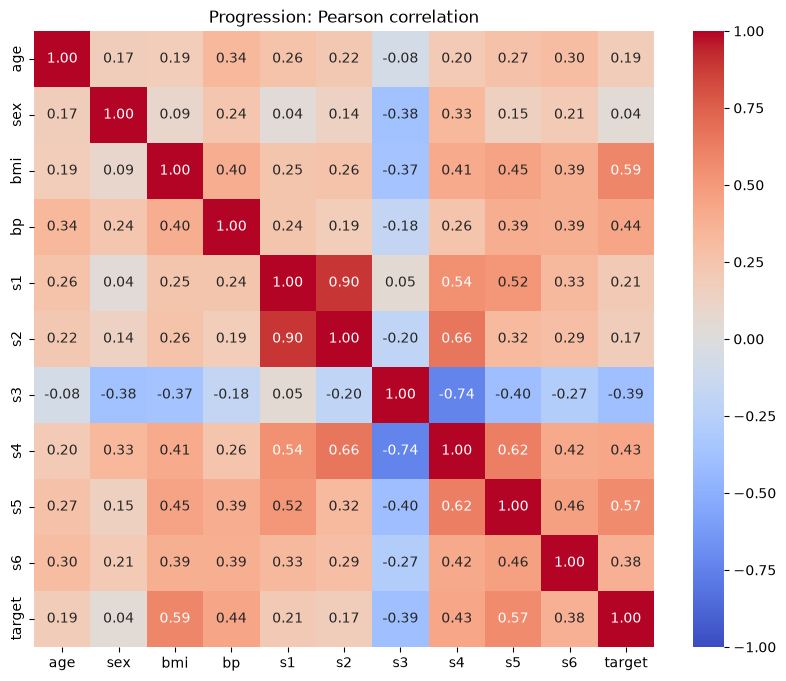

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64

In [20]:
prog_corr = prog.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(prog_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Progression: Pearson correlation")
plt.savefig("figures/fig10_prog_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

prog_corr["target"].drop("target").sort_values(ascending=False)

**Observation:** The features most correlated with progression are **bmi (0.59)** and **s5 (0.57, triglycerides)**, then bp (0.44) and s4 (0.43). **s3 (HDL, "good" cholesterol) is negative (−0.39)**: more HDL goes with less progression, which matches medicine. `sex` is almost unrelated (0.04). Two feature pairs are strongly correlated: **s1–s2 (0.90)** and s3–s4 (−0.74). This matters for Linear Regression, where such pairs make coefficients unstable, and is one reason we also try Ridge and Lasso.

## B.11 Progression: strongest relationships
Scatter plots of the two features most correlated with the target, with a straight-line fit.

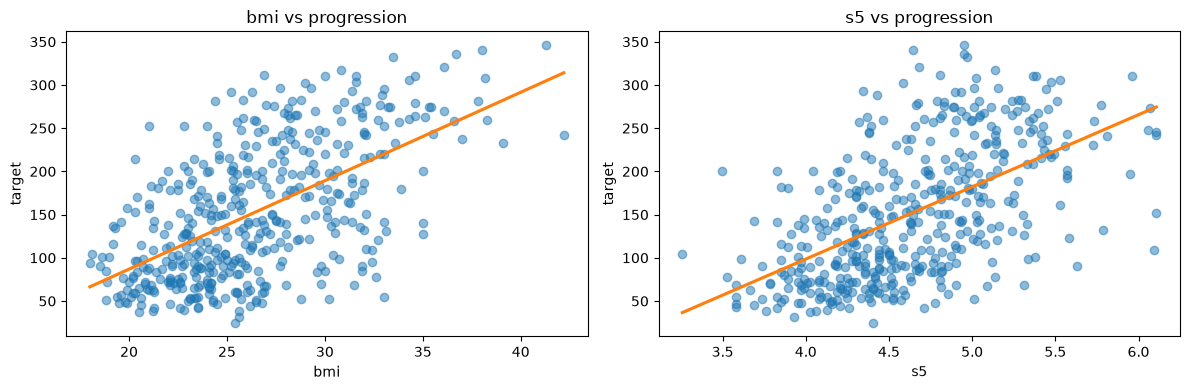

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["bmi", "s5"]):
    sns.regplot(data=prog, x=col, y="target", ax=ax, ci=None,
                scatter_kws={"alpha": 0.5}, line_kws={"color": "tab:orange"})
    ax.set_title(col + " vs progression")
plt.tight_layout()
plt.savefig("figures/fig11_prog_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Both scatter plots show a clear upward trend: patients with higher BMI or higher s5 tend to progress more. The points are widely scattered around the line, though, so one feature alone cannot predict progression accurately. We will need to combine several features, and we should expect a moderate R², not a near-perfect one.

## Key EDA Insights
1. **Glucose is the strongest signal for diabetes** (correlation 0.49 with Outcome; median 140 vs 107). This matches medicine, since diabetes is diagnosed from glucose, so we expect Glucose to be the top feature in every model and in SHAP (Section G).
2. **Pima has many hidden missing values**, especially Insulin (48.7%) and SkinThickness (29.6%). We converted the zeros to NaN and will fill them with the **training-set median inside a Pipeline** (Section C), to avoid leakage. The median is used because these columns are skewed.
3. **The classes are imbalanced (65.1% vs 34.9%)**, so accuracy is misleading. We will use a stratified split, `class_weight="balanced"`, and recall + ROC-AUC.
4. **BMI and body fat matter in both datasets**: BMI is the 2nd-strongest feature for diabetes (0.31) and the strongest for progression (0.59). BMI is *modifiable*, so it is the most useful finding for prevention advice.
5. **Features are on very different scales** (e.g. Insulin up to 846 vs DiabetesPedigreeFunction below 2.5; s1 around 189 vs s5 around 4.6). Distance- and coefficient-based models (Linear/Ridge/Lasso, Logistic Regression, KNN, SVM) need **StandardScaler**; tree models do not.
6. **Outliers are few and look like real patients**, so we keep them all. Tree-based models are hardly affected by extreme values, which is one reason to include them.
7. **Strongly correlated features in Progression (s1–s2: 0.90)** will make plain Linear Regression coefficients unstable. Ridge and Lasso should handle this, and Lasso may drop one of the pair (Section D).

# Section C: Preprocessing *(Rubric 3)*

**Data leakage** means information from the test set sneaking into training, for example computing the median or the mean/std for scaling on *all* the data. The test score then looks better than it would on truly new patients.

To prevent it:
1. Split the data into train and test sets **first**.
2. Put every step that learns something from the data (imputation, scaling) inside a scikit-learn **`Pipeline`**. A pipeline learns those values from the training data only, and only *applies* them to the test data.

In [22]:
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## C.1 Train/test split

80% of patients for training and 20% for the final test. The test set is not touched again until the final evaluation.
For Pima we use `stratify=y`, so both sets keep the same share of diabetics (about 35%). Without it, a random split could put noticeably more or fewer diabetics in the small test set.

In [23]:
X_pima = pima.drop(columns="Outcome")
y_pima = pima["Outcome"]

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, stratify=y_pima, random_state=RANDOM_STATE)

print("Train:", X_train_pima.shape, " Test:", X_test_pima.shape)
print("Diabetic share in train: %.3f" % y_train_pima.mean())
print("Diabetic share in test:  %.3f" % y_test_pima.mean())

Train: (614, 8)  Test: (154, 8)
Diabetic share in train: 0.349
Diabetic share in test:  0.351


**Observation:** Pima is split into **614 training** and **154 test** patients. Thanks to stratification, the share of diabetics is almost identical in both: **0.349 in train and 0.351 in test**, matching the 34.9% in the full data.

The progression target is a number, so there are no classes to stratify. We use a plain random 80/20 split.

In [24]:
X_prog = prog.drop(columns="target")
y_prog = prog["target"]

X_train_prog, X_test_prog, y_train_prog, y_test_prog = train_test_split(
    X_prog, y_prog, test_size=0.2, random_state=RANDOM_STATE)

print("Train:", X_train_prog.shape, " Test:", X_test_prog.shape)
print("Mean target in train: %.2f" % y_train_prog.mean())
print("Mean target in test:  %.2f" % y_test_prog.mean())

Train: (353, 10)  Test: (89, 10)
Mean target in train: 153.74
Mean target in test:  145.78


**Observation:** Progression is split into **353 training** and **89 test** patients. The mean target is 153.74 in train and 145.78 in test, so the test patients happen to progress a little less on average. This is normal random variation with only 89 patients. We do not adjust for it, because choosing a split by looking at the test set would itself be a form of leakage.

## C.2 Preprocessing steps

**1. Median imputation:** each missing value is replaced by the median of that column **in the training set**. We use the median because Insulin and SkinThickness are skewed (Section B).

**2. Standardisation:** each feature is rescaled to mean 0 and standard deviation 1:

$$z = \frac{x - \mu}{\sigma}$$
($x$ = original value, $\mu$ = training mean of the feature, $\sigma$ = training standard deviation)

**Which models get scaled?**
- **Scaled:** Linear/Ridge/Lasso, Logistic Regression, KNN, SVM. They use distances or coefficients, so a feature with large numbers (Insulin up to 846) would dominate one with small numbers (DiabetesPedigreeFunction below 2.5).
- **Not scaled:** Decision Tree, Random Forest, Gradient Boosting, Naive Bayes. Trees split on one feature at a time ("Glucose > 127?"), so the units do not matter. Naive Bayes models each feature on its own.

We will build 14 pipelines in total, so we write two small functions instead of repeating the same lines 14 times. The Progression data has no missing values, so the imputer simply does nothing there.

In [25]:
def make_scaled_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)])

def make_unscaled_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)])

## C.3 Checking that the pipeline prevents leakage

As a check, we fit just the two preprocessing steps on the Pima **training** set and look at what they learned and what they produce.

In [26]:
prep = Pipeline([("imputer", SimpleImputer(strategy="median")),
                 ("scaler", StandardScaler())])
prep.fit(X_train_pima)  # learns medians, means and stds from TRAINING data only

check = pd.DataFrame({
    "median (train)": prep.named_steps["imputer"].statistics_,
    "median (all data)": X_pima.median().values,
    "mean after scaling (train)": prep.transform(X_train_pima).mean(axis=0),
    "mean after scaling (test)": prep.transform(X_test_pima).mean(axis=0)},
    index=X_pima.columns)
check.round(3)

,median (train),median (all data),mean after scaling (train),mean after scaling (test)
Pregnancies,3.000,3.000,-0.0,0.039
Glucose,117.000,117.000,-0.0,-0.002
BloodPressure,72.000,72.000,0.0,0.100
SkinThickness,29.000,29.000,-0.0,0.037
Insulin,125.000,125.000,-0.0,0.188
BMI,32.400,32.300,0.0,0.006
DiabetesPedigreeFunction,0.382,0.372,-0.0,-0.084
Age,29.000,29.000,-0.0,-0.053


**Observation:** The **training medians** are close to the medians of the full data but not always the same (BMI 32.4 vs 32.3, DiabetesPedigreeFunction 0.382 vs 0.372). This shows the imputer learned only from the training rows. The Insulin median is now 125, not the 30.5 we saw in Section A, because the impossible zeros no longer pull it down. After scaling, every training mean is 0 (`-0.0` is just a tiny negative number rounded). The test means are **not exactly 0** (e.g. Insulin 0.188), because the test set is scaled with the *training* mean and std, exactly as would happen with brand-new patients. This is the pipeline preventing leakage.

## C.4 Cross-validation setup

To compare models we use **5-fold cross-validation** on the training set only. The training data is cut into 5 parts; each model is trained 5 times, each time on 4 parts and scored on the remaining part. We report the **mean ± standard deviation** of the 5 scores:

$$\text{CV score} = \frac{1}{5}\sum_{k=1}^{5} \text{score}_k$$
($\text{score}_k$ = the score on fold $k$; the standard deviation shows how much the score changes from fold to fold)

`StratifiedKFold` keeps about 35% diabetics in every fold. `shuffle=True` with our seed mixes the rows first, in the same way on every run.

In [27]:
cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Section D: Regression on the Progression data *(Rubric 3)*

## D.1 Models

| Model | Idea | Formula |
|---|---|---|
| Baseline | Always predict the training mean | $\hat{y} = \bar{y}$ |
| Linear Regression | Straight-line combination of features, chosen to minimise squared error | $\hat{y} = \beta_0 + \sum_j \beta_j x_j$, minimise $\sum_i (y_i - \hat{y}_i)^2$ |
| Ridge | Linear + penalty on large coefficients (helps with correlated features like s1–s2) | minimise $\sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j \beta_j^2$ |
| Lasso | Linear + penalty that can push coefficients to exactly 0 (feature selection) | minimise $\sum_i (y_i - \hat{y}_i)^2 + \alpha \sum_j \lvert\beta_j\rvert$ |
| KNN | Average target of the $k$ most similar patients ($k=5$) | $\hat{y} = \frac{1}{k}\sum_{i \in N_k(x)} y_i$ |
| Decision Tree | Splits patients with yes/no questions that reduce the MSE the most | split minimising $\frac{n_L}{n}\text{MSE}_L + \frac{n_R}{n}\text{MSE}_R$ |
| Random Forest | Average of many trees, each trained on a random sample | $\hat{y} = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$ |
| Gradient Boosting | Trees added one by one, each fixing the errors of the previous ones | $F_m(x) = F_{m-1}(x) + \eta\, h_m(x)$ |

$\beta_j$ = coefficient of feature $j$, $\alpha$ = penalty strength, $N_k(x)$ = the $k$ nearest patients, $n_L, n_R$ = patients sent left/right by a split, $B$ = number of trees, $T_b$ = tree $b$, $h_m$ = new tree fitted to the residuals $y - F_{m-1}(x)$, $\eta$ = learning rate.

In [28]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

reg_models = {
    "Baseline (mean)": make_unscaled_pipeline(DummyRegressor()),
    "Linear Regression": make_scaled_pipeline(LinearRegression()),
    "Ridge": make_scaled_pipeline(Ridge()),
    "Lasso": make_scaled_pipeline(Lasso()),
    "KNN": make_scaled_pipeline(KNeighborsRegressor()),
    "Decision Tree": make_unscaled_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    "Random Forest": make_unscaled_pipeline(RandomForestRegressor(random_state=RANDOM_STATE)),
    "Gradient Boosting": make_unscaled_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
}

## D.2 Cross-validation

Each model is scored with 5-fold CV on the training set using:

$$\text{MAE} = \frac{1}{n}\sum|y_i - \hat{y}_i| \qquad \text{MSE} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 \qquad \text{RMSE} = \sqrt{\text{MSE}} \qquad R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

MAE and RMSE are in the target's units (lower is better); $R^2$ is the share of variation explained (higher is better).
scikit-learn returns errors as negative numbers (so that "higher is better" for every score), so we flip their sign.

In [29]:
rows = []
for name, model in reg_models.items():
    cv = cross_validate(model, X_train_prog, y_train_prog, cv=cv_reg, return_train_score=True,
                        scoring=["neg_mean_absolute_error", "neg_mean_squared_error", "r2"])
    mae = -cv["test_neg_mean_absolute_error"]   # flip the sign back to positive
    mse = -cv["test_neg_mean_squared_error"]
    rmse = np.sqrt(mse)                          # RMSE of each fold
    r2 = cv["test_r2"]
    rows.append([name, mae.mean(), mae.std(), mse.mean(), mse.std(), rmse.mean(), rmse.std(),
                 r2.mean(), r2.std(), cv["train_r2"].mean(), cv["fit_time"].mean()])

reg_cv = pd.DataFrame(rows, columns=["model", "MAE", "MAE std", "MSE", "MSE std", "RMSE",
                      "RMSE std", "R2", "R2 std", "R2 train", "fit time (s)"])
reg_cv = reg_cv.sort_values("R2", ascending=False)
reg_cv.round(3)

,model,MAE,MAE std,MSE,MSE std,RMSE,RMSE std,R2,R2 std,R2 train,fit time (s)
2,Ridge,44.999,1.808,3071.931,266.417,55.374,2.373,0.481,0.040,0.530,0.004
3,Lasso,45.136,1.991,3073.288,258.870,55.388,2.325,0.481,0.036,0.525,0.005
1,Linear Regression,45.048,1.773,3074.142,265.186,55.395,2.361,0.480,0.041,0.531,0.003
6,Random Forest,48.575,3.089,3543.121,241.756,59.489,2.038,0.398,0.071,0.920,0.144
7,Gradient Boosting,49.454,3.075,3737.492,364.062,61.064,2.946,0.369,0.054,0.874,0.100
4,KNN,49.442,4.053,3870.520,461.437,62.110,3.580,0.345,0.081,0.572,0.004
0,Baseline (mean),66.867,5.632,6136.655,870.972,78.134,5.638,-0.027,0.024,0.000,0.004
5,Decision Tree,61.704,7.663,6547.547,1450.931,80.318,9.823,-0.106,0.267,1.000,0.006


**Observation:** The three linear models are best and almost tied: **Ridge 0.481, Lasso 0.481, Linear 0.480** CV R², with RMSE about 55. The gap between them is far smaller than the CV std (about 0.04), so they are effectively equal. All models beat the mean baseline (R² −0.027) except the **Decision Tree (−0.106)**, which overfits badly: train R² 1.000 vs CV −0.106. Random Forest (train 0.920 vs CV 0.398) also overfits, while the linear models' train and CV R² are close (about 0.53 vs 0.48). The relationship in this data looks mostly linear, so the simple models win.

## D.3 Tuning the best two models

The two best models in CV are **Ridge** and **Lasso**. Their only important hyperparameter is the penalty strength $\alpha$: small $\alpha$ is close to plain Linear Regression, large $\alpha$ shrinks the coefficients more.
`GridSearchCV` tries every value with the same 5-fold CV and keeps the best one. `model__alpha` means "the `alpha` of the pipeline step called `model`".

In [30]:
alphas = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(make_scaled_pipeline(Ridge()), alphas, cv=cv_reg, scoring="r2")
ridge_grid.fit(X_train_prog, y_train_prog)

lasso_grid = GridSearchCV(make_scaled_pipeline(Lasso()), alphas, cv=cv_reg, scoring="r2")
lasso_grid.fit(X_train_prog, y_train_prog)

print("Ridge best:", ridge_grid.best_params_, " CV R2 = %.4f" % ridge_grid.best_score_)
print("Lasso best:", lasso_grid.best_params_, " CV R2 = %.4f" % lasso_grid.best_score_)

Ridge best: {'model__alpha': 1}  CV R2 = 0.4808
Lasso best: {'model__alpha': 0.1}  CV R2 = 0.4812


**Observation:** Tuning barely changes anything. Ridge keeps its default α = 1 (CV R² 0.4808), and Lasso's best is α = 0.1 (CV R² 0.4812). Lasso is higher by only 0.0004, which is far inside the CV std, so we pick **Lasso (α = 0.1)** simply because it has the higher score.

## D.4 Final test-set evaluation

We take the tuned model with the higher CV $R^2$ and evaluate it **once** on the test set, next to the mean baseline.

In [31]:
best_reg = lasso_grid.best_estimator_     # already refitted on the full training set
y_pred_prog = best_reg.predict(X_test_prog)
baseline_pred = np.full(len(y_test_prog), y_train_prog.mean())

print("Model     test MAE = %.2f  RMSE = %.2f  R2 = %.3f" % (
    mean_absolute_error(y_test_prog, y_pred_prog),
    root_mean_squared_error(y_test_prog, y_pred_prog), r2_score(y_test_prog, y_pred_prog)))
print("Baseline  test MAE = %.2f  RMSE = %.2f  R2 = %.3f" % (
    mean_absolute_error(y_test_prog, baseline_pred),
    root_mean_squared_error(y_test_prog, baseline_pred), r2_score(y_test_prog, baseline_pred)))

Model     test MAE = 42.81  RMSE = 53.71  R2 = 0.456
Baseline  test MAE = 64.01  RMSE = 73.22  R2 = -0.012


**Observation:** On the unseen test set the tuned Lasso reaches **R² = 0.456, RMSE = 53.71 and MAE = 42.81**, against R² −0.012 and RMSE 73.22 for the mean baseline. This **meets our success criterion** (R² ≥ 0.40, clearly above the baseline). The test R² is close to the CV R² (0.481), so the model generalises as expected.

**Predicted vs actual:** points on the dashed line are perfect predictions. **Residual plot:** residual $= y - \hat{y}$; a good model has residuals scattered randomly around 0 with no pattern.

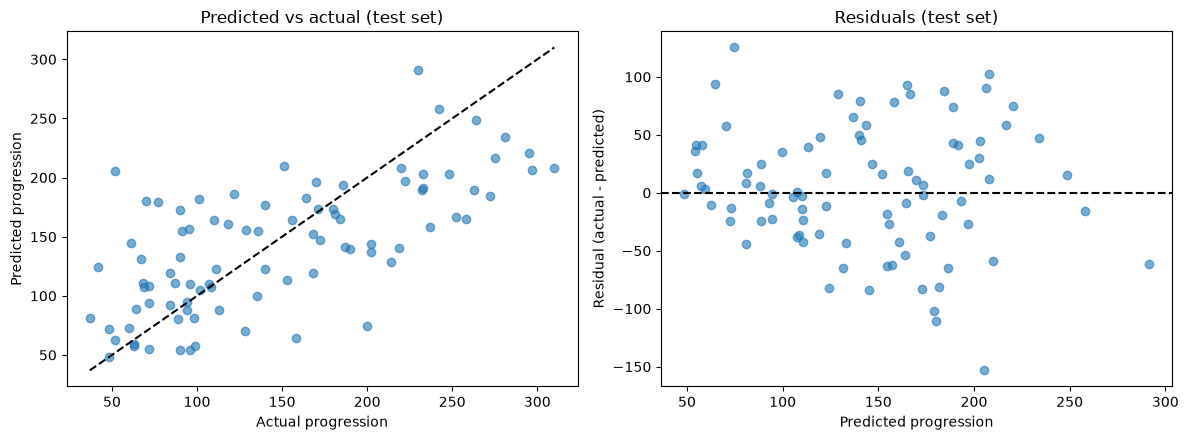

In [32]:
residuals = y_test_prog - y_pred_prog

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test_prog, y_pred_prog, alpha=0.6)
lims = [y_test_prog.min(), y_test_prog.max()]
axes[0].plot(lims, lims, "k--")               # perfect-prediction line
axes[0].set_xlabel("Actual progression")
axes[0].set_ylabel("Predicted progression")
axes[0].set_title("Predicted vs actual (test set)")

axes[1].scatter(y_pred_prog, residuals, alpha=0.6)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted progression")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals (test set)")
plt.tight_layout()
plt.savefig("figures/fig12_reg_test_plots.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** The points follow the dashed line but with a wide spread. High actual values tend to be **under-predicted** and low ones **over-predicted**, so the model pulls predictions towards the middle, which is typical when R² is only about 0.46. The residuals are scattered around 0 with no clear curve, so a linear model is reasonable. Many errors are around ±50 to ±100, though, so individual predictions are rough.

## D.5 Coefficients and Lasso feature selection

The features were standardised, so each coefficient is the change in predicted progression for a **1 standard deviation increase** in that feature, keeping the others fixed. The sign gives the direction and the size gives the strength.

In [33]:
linear = make_scaled_pipeline(LinearRegression()).fit(X_train_prog, y_train_prog)

coefs = pd.DataFrame({
    "Linear": linear.named_steps["model"].coef_,
    "Ridge": ridge_grid.best_estimator_.named_steps["model"].coef_,
    "Lasso": lasso_grid.best_estimator_.named_steps["model"].coef_},
    index=X_train_prog.columns)
coefs.round(2).sort_values("Linear")

,Linear,Ridge,Lasso
s1,-44.45,-34.67,-29.36
sex,-11.51,-11.45,-11.32
age,1.75,1.81,1.73
s6,2.35,2.46,2.39
s3,7.68,3.37,0.55
s4,13.14,11.76,10.24
bp,16.83,16.73,16.64
s2,24.64,17.05,13.28
bmi,25.61,25.73,25.82
s5,35.16,31.38,29.63


**Lasso feature selection:** at the tuned $lpha$ Lasso keeps every feature. To see which features it drops first, we refit it with stronger penalties.

In [34]:
for alpha in [0.1, 1, 3, 5, 10]:
    lasso = make_scaled_pipeline(Lasso(alpha=alpha)).fit(X_train_prog, y_train_prog)
    zero = X_train_prog.columns[lasso.named_steps["model"].coef_ == 0]
    print("alpha =", alpha, "-> set to zero:", list(zero))

alpha = 0.1 -> set to zero: []
alpha = 1 -> set to zero: ['s2']
alpha = 3 -> set to zero: ['age', 's2', 's4']
alpha = 5 -> set to zero: ['age', 's1', 's2', 's4', 's6']
alpha = 10 -> set to zero: ['age', 'sex', 's1', 's2', 's4', 's6']


**Observation:** **s5 (triglycerides, about +30), bmi (about +26) and bp (about +17)** raise predicted progression the most, which matches medicine and the EDA correlations. **s1 has a large negative coefficient (−44 in Linear) while s2 is positive (+25)**. Because s1 and s2 are 0.90 correlated, the model offsets one against the other, so s1's sign should not be read as "cholesterol is protective". Ridge and Lasso shrink this pair (s1 −29, s2 13 in Lasso). Similarly, s3 (HDL) is negatively correlated with the target (−0.39) but has a small positive coefficient, because s4 already contains HDL. At the tuned α Lasso drops nothing; with stronger penalties it removes **s2 first (α = 1)**, then age and s4 (α = 3). This is feature selection, and it removes the features that are redundant or carry little signal.

# Section E: Classification on the Pima data *(Rubric 3)*

## E.1 Models

| Model | Idea | Formula |
|---|---|---|
| Logistic Regression | Linear score turned into a probability; trained by minimising log-loss | $\hat{p} = \sigma(z) = \frac{1}{1+e^{-z}},\ z = \beta_0 + \sum_j \beta_j x_j$; loss $= -\frac{1}{n}\sum [y\log\hat{p} + (1-y)\log(1-\hat{p})]$ |
| KNN | Majority class of the $k=5$ nearest patients | $d(a,b) = \sqrt{\sum_j (a_j - b_j)^2}$ |
| Gaussian Naive Bayes | Bayes' theorem, assuming features are independent and normally distributed within each class | $P(y \mid \mathbf{x}) \propto P(y)\prod_j P(x_j \mid y)$ |
| Decision Tree | Yes/no splits that make the groups as pure as possible | Gini $= 1 - \sum_c p_c^2$ |
| Random Forest | Majority vote of many trees, each on a random sample | $\hat{y} = \text{mode}\{T_1(x), \dots, T_B(x)\}$ |
| SVM (RBF kernel) | Boundary with the widest margin between classes, made curved by the kernel | maximise margin $\frac{2}{\lVert w \rVert}$; $K(a,b) = e^{-\gamma\lVert a-b\rVert^2}$ |
| Gradient Boosting | Trees added one by one, each correcting the previous errors | $F_m(x) = F_{m-1}(x) + \eta\, h_m(x)$ |

$\sigma$ = sigmoid, $p_c$ = share of class $c$ in a node, $\gamma$ = how far one patient's influence reaches, $w$ = the boundary's weight vector.

**Class imbalance:** only about 35% are diabetic, so models that support it get `class_weight="balanced"`, which gives each class the weight $w_c = \frac{n}{2\, n_c}$ ($n$ = patients, $n_c$ = patients in class $c$). Mistakes on the smaller diabetic class then cost more. KNN, Naive Bayes and Gradient Boosting do not have this option.

In [35]:
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
                             roc_auc_score, recall_score, precision_score)

# SVC(probability=True) still works in our scikit-learn version but prints a "deprecated" warning
warnings.filterwarnings("ignore", category=FutureWarning)

In [36]:
clf_models = {
    "Logistic Regression": make_scaled_pipeline(LogisticRegression(class_weight="balanced", max_iter=1000)),
    "KNN": make_scaled_pipeline(KNeighborsClassifier()),
    "Naive Bayes": make_unscaled_pipeline(GaussianNB()),
    "Decision Tree": make_unscaled_pipeline(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    "Random Forest": make_unscaled_pipeline(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    "SVM": make_scaled_pipeline(SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
    "Gradient Boosting": make_unscaled_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
}

## E.2 Cross-validation

From the confusion matrix ($TP$ = diabetics caught, $FN$ = diabetics missed, $FP$ = false alarms, $TN$ = healthy correctly cleared):

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \quad \text{Precision} = \frac{TP}{TP+FP} \quad \text{Recall} = \frac{TP}{TP+FN} \quad F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**ROC-AUC** is the area under the curve of recall (true positive rate) against the false positive rate $\frac{FP}{FP+TN}$, over all thresholds: 0.5 = guessing, 1 = perfect.
Recall is our main metric, because missing a diabetic is worse than a false alarm. The table is sorted by it.

In [37]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for name, model in clf_models.items():
    cv = cross_validate(model, X_train_pima, y_train_pima, cv=cv_class,
                        scoring=scoring, return_train_score=True)
    row = {"model": name}
    for s in scoring:
        row[s] = cv["test_" + s].mean()
        row[s + " std"] = cv["test_" + s].std()
    row["roc_auc train"] = cv["train_roc_auc"].mean()   # used later to check overfitting
    row["fit time (s)"] = cv["fit_time"].mean()
    rows.append(row)

clf_cv = pd.DataFrame(rows).sort_values("recall", ascending=False)
clf_cv.round(3)

,model,accuracy,accuracy std,precision,precision std,recall,recall std,f1,f1 std,roc_auc,roc_auc std,roc_auc train,fit time (s)
5,SVM,0.761,0.034,0.637,0.062,0.762,0.052,0.690,0.029,0.837,0.031,0.909,0.023
0,Logistic Regression,0.762,0.011,0.649,0.026,0.701,0.039,0.672,0.013,0.844,0.016,0.852,0.010
4,Random Forest,0.764,0.028,0.654,0.047,0.701,0.010,0.675,0.022,0.820,0.027,1.000,0.153
2,Naive Bayes,0.762,0.028,0.686,0.059,0.598,0.052,0.637,0.038,0.828,0.010,0.833,0.003
6,Gradient Boosting,0.756,0.018,0.672,0.051,0.598,0.031,0.631,0.013,0.819,0.016,0.989,0.127
1,KNN,0.730,0.041,0.637,0.089,0.565,0.056,0.594,0.047,0.784,0.037,0.906,0.004
3,Decision Tree,0.673,0.029,0.532,0.041,0.533,0.022,0.532,0.030,0.640,0.026,1.000,0.006


**Observation:** **SVM has the highest recall (0.762)** and is the only model above our 0.75 target in CV. **Logistic Regression has the highest ROC-AUC (0.844)**. Accuracy hardly separates the top five models (0.756–0.764), which shows why accuracy is not our metric. The three models without `class_weight` (Naive Bayes 0.598, Gradient Boosting 0.598, KNN 0.565) have the lowest recall, partly because they do not give diabetics extra weight. Tree models overfit: train ROC-AUC is 1.000 for the Decision Tree and Random Forest, against CV 0.640 and 0.820. Logistic Regression's train and CV scores are close (0.852 vs 0.844).

## E.3 Tuning the best two models

The two best models by ROC-AUC are **Logistic Regression** and **SVM**. We tune on **ROC-AUC rather than recall**: recall alone can be "won" by calling everyone diabetic, while ROC-AUC rewards ranking patients correctly. Recall is then raised with the threshold (E.5).
- Logistic Regression: `C` = how weakly the coefficients are penalised (small `C` = stronger penalty).
- SVM: `C` (how much training errors are punished) and `gamma` (how curved the boundary can be).

In [38]:
lr_grid = GridSearchCV(clf_models["Logistic Regression"],
                       {"model__C": [0.01, 0.1, 1, 10]}, cv=cv_class, scoring="roc_auc")
lr_grid.fit(X_train_pima, y_train_pima)

svm_grid = GridSearchCV(clf_models["SVM"],
                        {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1]},
                        cv=cv_class, scoring="roc_auc")
svm_grid.fit(X_train_pima, y_train_pima)

print("Logistic Regression best:", lr_grid.best_params_, " CV ROC-AUC = %.4f" % lr_grid.best_score_)
print("SVM best:", svm_grid.best_params_, " CV ROC-AUC = %.4f" % svm_grid.best_score_)

Logistic Regression best: {'model__C': 0.1}  CV ROC-AUC = 0.8450
SVM best: {'model__C': 1, 'model__gamma': 0.01}  CV ROC-AUC = 0.8493


**Observation:** Logistic Regression improves only slightly (0.844 → 0.8450, with C = 0.1). **SVM improves more (0.837 → 0.8493)** with C = 1 and gamma = 0.01. A small gamma gives a smooth, almost linear boundary, which suggests the data does not need a very curved one. Tuned SVM is our final classifier, but its lead over Logistic Regression (0.004) is well inside the CV std (about 0.02–0.03).

## E.4 Final test-set evaluation (threshold 0.5)

The tuned model with the higher CV ROC-AUC is evaluated once on the test set. We turn its probabilities into labels ourselves ($\hat{p} \ge 0.5$), so that the same rule is used in the threshold analysis below. (For SVM, `predict()` uses its own decision score and can disagree with `predict_proba`.)

In [39]:
best_clf = svm_grid.best_estimator_
y_proba_pima = best_clf.predict_proba(X_test_pima)[:, 1]  # probability of diabetes
y_pred_pima = (y_proba_pima >= 0.5).astype(int)          # flag if probability >= 0.5

print("Test ROC-AUC = %.3f" % roc_auc_score(y_test_pima, y_proba_pima))
print(classification_report(y_test_pima, y_pred_pima, target_names=["not diabetic", "diabetic"]))

Test ROC-AUC = 0.810
              precision    recall  f1-score   support

not diabetic       0.75      0.82      0.78       100
    diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



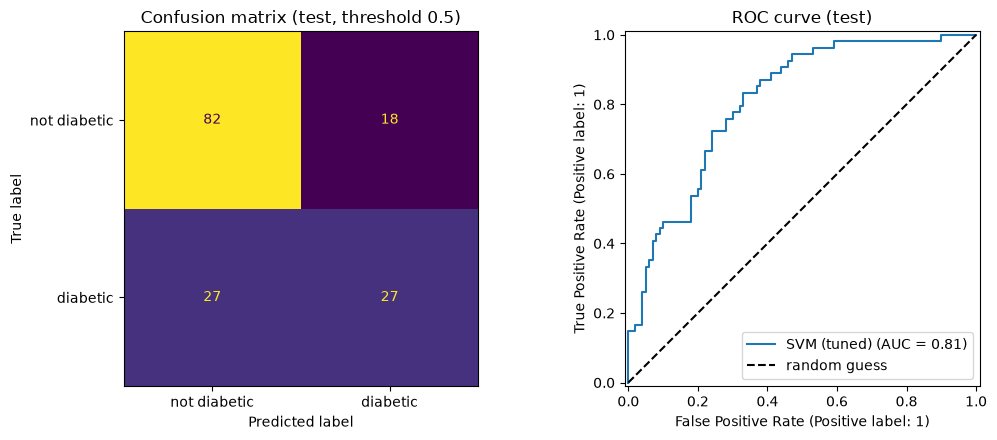

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test_pima, y_pred_pima, ax=axes[0], colorbar=False,
                                        display_labels=["not diabetic", "diabetic"])
axes[0].set_title("Confusion matrix (test, threshold 0.5)")
RocCurveDisplay.from_predictions(y_test_pima, y_proba_pima, ax=axes[1], name="SVM (tuned)")
axes[1].plot([0, 1], [0, 1], "k--", label="random guess")
axes[1].legend(loc="lower right")
axes[1].set_title("ROC curve (test)")
plt.tight_layout()
plt.savefig("figures/fig13_clf_test_cm_roc.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Test **ROC-AUC = 0.810**, which meets our ≥ 0.80 target (it is lower than CV's 0.849, which is normal for a 154-patient test set). At the default threshold of 0.5, however, the model catches only **27 of 54 diabetics (recall 0.50)**, far below our 0.75 target, with 18 false alarms. The model ranks patients well, but 0.5 is the wrong cut-off for screening.

## E.5 Threshold analysis

A patient is flagged as diabetic if $\hat{p} \ge t$. Lowering $t$ flags more patients: **recall goes up, precision goes down**.
We must **not** choose $t$ by looking at the test set, as that would be leakage. Instead we get out-of-fold probabilities for the training patients with `cross_val_predict` (each patient is predicted by a model that did not see them) and choose $t$ from those.

In [41]:
train_proba = cross_val_predict(best_clf, X_train_pima, y_train_pima,
                                cv=cv_class, method="predict_proba")[:, 1]

rows = []
for t in [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]:
    flagged = (train_proba >= t).astype(int)
    rows.append([t, recall_score(y_train_pima, flagged),
                 precision_score(y_train_pima, flagged), flagged.mean()])
thresholds = pd.DataFrame(rows, columns=["threshold", "recall", "precision", "share flagged"])
thresholds.round(3)

,threshold,recall,precision,share flagged
0,0.50,0.589,0.728,0.282
1,0.45,0.650,0.724,0.313
2,0.40,0.687,0.671,0.357
3,0.35,0.738,0.637,0.404
4,0.30,0.780,0.592,0.459
5,0.25,0.846,0.564,0.523
6,0.20,0.916,0.537,0.594


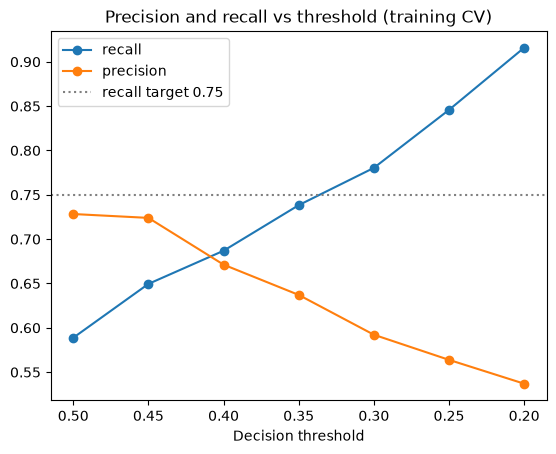

In [42]:
plt.plot(thresholds["threshold"], thresholds["recall"], marker="o", label="recall")
plt.plot(thresholds["threshold"], thresholds["precision"], marker="o", label="precision")
plt.axhline(0.75, color="gray", linestyle=":", label="recall target 0.75")
plt.gca().invert_xaxis()                       # read left to right: 0.5 -> lower
plt.xlabel("Decision threshold")
plt.legend()
plt.title("Precision and recall vs threshold (training CV)")
plt.savefig("figures/fig14_clf_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** As the threshold drops from 0.5 to 0.2, CV recall rises from **0.589 to 0.916** while precision falls from 0.728 to 0.537, and the share of patients flagged grows from 28.2% to 59.4%. Recall crosses our 0.75 target between t = 0.35 (0.738) and t = 0.30 (0.780).

**Chosen threshold:** we use the **highest threshold whose training-CV recall reaches our 0.75 target: t = 0.30** (CV recall 0.780, precision 0.592, 45.9% of patients flagged). Lower thresholds would catch even more diabetics, but flag many more healthy people (t = 0.20 flags 59.4%). For a cheap first screen followed by a confirmatory blood test, a false alarm costs little and a missed diabetic costs a lot, so this trade-off is acceptable. The threshold was chosen from training data only; the test set is used once, below.

Test recall    = 0.796
Test precision = 0.566


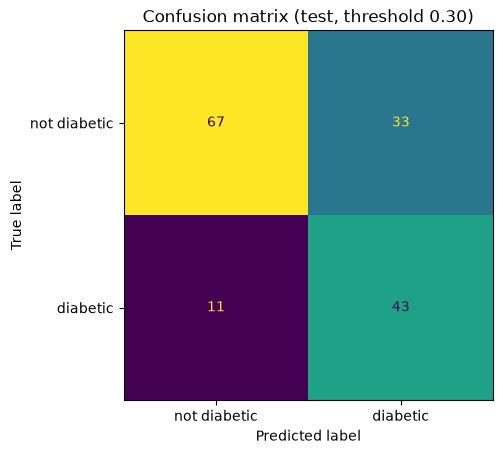

In [43]:
THRESHOLD = 0.30
y_pred_screen = (y_proba_pima >= THRESHOLD).astype(int)

print("Test recall    = %.3f" % recall_score(y_test_pima, y_pred_screen))
print("Test precision = %.3f" % precision_score(y_test_pima, y_pred_screen))
ConfusionMatrixDisplay.from_predictions(y_test_pima, y_pred_screen, colorbar=False,
                                        display_labels=["not diabetic", "diabetic"])
plt.title("Confusion matrix (test, threshold %.2f)" % THRESHOLD)
plt.savefig("figures/fig15_clf_cm_screening.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** With t = 0.30 the model catches **43 of 54 diabetics (test recall 0.796)**, compared with 27 at t = 0.5, which **meets our recall ≥ 0.75 target**. The price is more false alarms (33 instead of 18), so precision is 0.566: about 57% of flagged patients are actually diabetic. Catching 16 more diabetics for 15 more follow-up tests is a good trade for screening. 11 diabetics are still missed (false negatives); Section G looks at why.

# Section F: Comparative Performance Analysis *(Rubric 4)*

## F.1 Comparison tables

We fit every (untuned) model on the full training set and score it once on the test set, then put it next to its train and CV scores.
Comparing **train vs CV vs test** shows overfitting: a model that is much better on train than on CV/test has memorised the training data.

In [44]:
reg_test = {}
for name, model in reg_models.items():
    model.fit(X_train_prog, y_train_prog)
    reg_test[name] = r2_score(y_test_prog, model.predict(X_test_prog))

reg_compare = reg_cv[["model", "R2 train", "R2", "R2 std", "RMSE", "fit time (s)"]].copy()
reg_compare = reg_compare.rename(columns={"R2": "R2 CV", "R2 std": "R2 CV std", "RMSE": "RMSE CV"})
reg_compare["R2 test"] = reg_compare["model"].map(reg_test)
reg_compare.round(3)

,model,R2 train,R2 CV,R2 CV std,RMSE CV,fit time (s),R2 test
2,Ridge,0.530,0.481,0.040,55.374,0.004,0.454
3,Lasso,0.525,0.481,0.036,55.388,0.005,0.467
1,Linear Regression,0.531,0.480,0.041,55.395,0.003,0.453
6,Random Forest,0.920,0.398,0.071,59.489,0.144,0.443
7,Gradient Boosting,0.874,0.369,0.054,61.064,0.100,0.455
4,KNN,0.572,0.345,0.081,62.110,0.004,0.425
0,Baseline (mean),0.000,-0.027,0.024,78.134,0.004,-0.012
5,Decision Tree,1.000,-0.106,0.267,80.318,0.006,0.078


**Observation:** The linear models are consistent: about 0.53 train, 0.48 CV and 0.45–0.47 test R², so they do **not overfit**. The tree models do: the Decision Tree goes from 1.000 (train) to −0.106 (CV) and 0.078 (test); Random Forest from 0.920 to 0.398 and 0.443; Gradient Boosting from 0.874 to 0.369 and 0.455. On the 89-patient test set the gaps between models shrink (Lasso 0.467, Gradient Boosting 0.455, Ridge 0.454, Random Forest 0.443). Five CV folds are a more reliable basis for ranking than this one small test set.

For classification, test recall uses each model's default `predict()`, the same rule as the CV recall in E.2. We also keep each model's test probabilities for the ROC plot.

In [45]:
clf_test_recall, clf_test_auc, clf_proba = {}, {}, {}
for name, model in clf_models.items():
    model.fit(X_train_pima, y_train_pima)
    clf_proba[name] = model.predict_proba(X_test_pima)[:, 1]
    clf_test_recall[name] = recall_score(y_test_pima, model.predict(X_test_pima))
    clf_test_auc[name] = roc_auc_score(y_test_pima, clf_proba[name])

clf_compare = clf_cv[["model", "recall", "recall std", "roc_auc train", "roc_auc",
                      "roc_auc std", "fit time (s)"]].copy()
clf_compare["recall test"] = clf_compare["model"].map(clf_test_recall)
clf_compare["roc_auc test"] = clf_compare["model"].map(clf_test_auc)
clf_compare.round(3)

,model,recall,recall std,roc_auc train,roc_auc,roc_auc std,fit time (s),recall test,roc_auc test
5,SVM,0.762,0.052,0.909,0.837,0.031,0.023,0.722,0.814
0,Logistic Regression,0.701,0.039,0.852,0.844,0.016,0.010,0.704,0.813
4,Random Forest,0.701,0.010,1.000,0.820,0.027,0.153,0.667,0.821
2,Naive Bayes,0.598,0.052,0.833,0.828,0.010,0.003,0.630,0.765
6,Gradient Boosting,0.598,0.031,0.989,0.819,0.016,0.127,0.556,0.831
1,KNN,0.565,0.056,0.906,0.784,0.037,0.004,0.611,0.790
3,Decision Tree,0.533,0.022,1.000,0.640,0.026,0.006,0.481,0.661


**Observation:** SVM has the best recall in both CV (0.762) and test (0.722), ahead of Logistic Regression (0.701 / 0.704). On test ROC-AUC, Gradient Boosting (0.831), Random Forest (0.821), SVM (0.814) and Logistic Regression (0.813) are all within 0.02 of each other, which is less than the CV std (about 0.02–0.03). The Decision Tree and Random Forest reach 1.000 train ROC-AUC and Gradient Boosting 0.989, a clear sign of overfitting. Logistic Regression's train, CV and test scores are close (0.852 / 0.844 / 0.813).

## F.2 Main metric with CV error bars

Each bar is the CV mean; the black line is ± 1 standard deviation across the 5 folds. If two error bars overlap a lot, the difference between those models is not reliable.

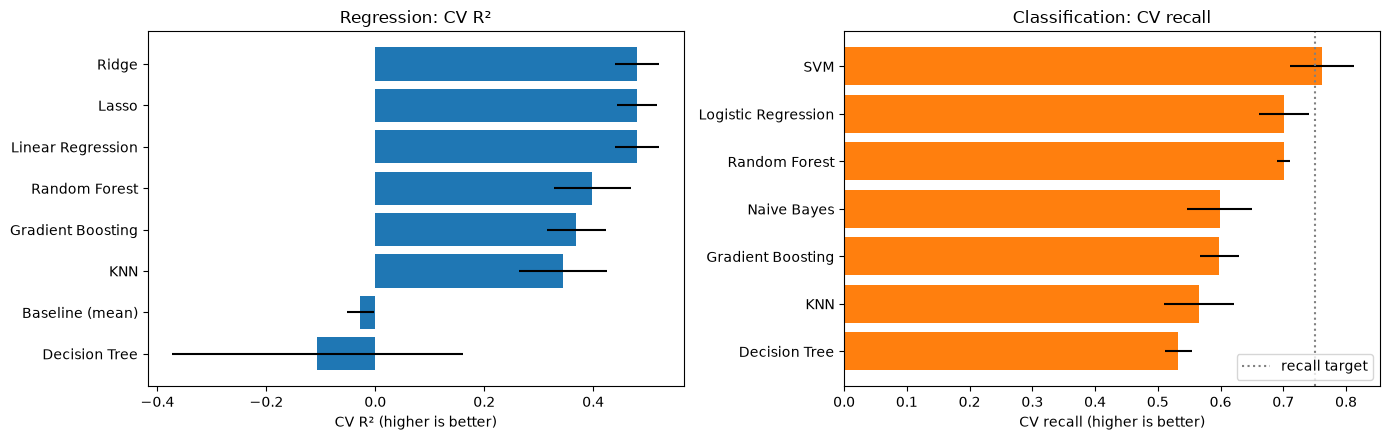

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(reg_cv["model"], reg_cv["R2"], xerr=reg_cv["R2 std"], color="tab:blue")
axes[0].set_xlabel("CV R² (higher is better)")
axes[0].set_title("Regression: CV R²")
axes[0].invert_yaxis()                     # best model at the top

axes[1].barh(clf_cv["model"], clf_cv["recall"], xerr=clf_cv["recall std"], color="tab:orange")
axes[1].axvline(0.75, color="gray", linestyle=":", label="recall target")
axes[1].set_xlabel("CV recall (higher is better)")
axes[1].set_title("Classification: CV recall")
axes[1].invert_yaxis()
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/fig16_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** In regression, the three linear models have the same bar height and overlapping error bars, so they are tied. The Decision Tree's error bar is very wide (std 0.267), so it is unstable as well as poor. In classification, only SVM reaches the 0.75 recall line on average, but its error bar overlaps those of Logistic Regression and Random Forest, so its lead is not certain.

## F.3 ROC curves of all classifiers (test set)

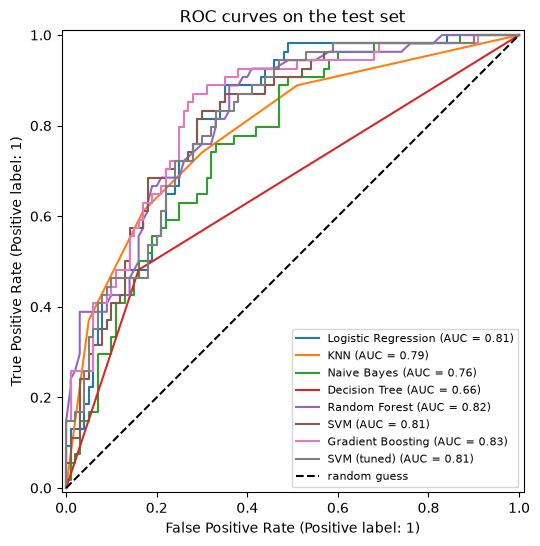

In [47]:
clf_proba["SVM (tuned)"] = y_proba_pima        # add the final tuned model

fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in clf_proba.items():
    RocCurveDisplay.from_predictions(y_test_pima, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="random guess")
ax.legend(fontsize=8)
ax.set_title("ROC curves on the test set")
plt.savefig("figures/fig17_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Apart from the Decision Tree (AUC 0.66), all curves lie close together (AUC 0.76–0.83) and cross each other several times, so no model is better at every threshold. The Decision Tree's curve has only a few corners because a fully grown tree gives almost only 0/1 probabilities, so it cannot rank patients finely.

## F.4 Before vs after tuning

"Before" = default settings, "after" = best settings from `GridSearchCV`. Regression is scored with $R^2$ and classification with ROC-AUC (the tuning metrics). `grid.score()` uses the same metric the grid search was tuned on.

In [48]:
r = reg_cv.set_index("model")
c = clf_cv.set_index("model")

tuning = pd.DataFrame({
    "metric": ["R2", "R2", "ROC-AUC", "ROC-AUC"],
    "CV before": [r.loc["Ridge", "R2"], r.loc["Lasso", "R2"],
                  c.loc["Logistic Regression", "roc_auc"], c.loc["SVM", "roc_auc"]],
    "CV after": [ridge_grid.best_score_, lasso_grid.best_score_, lr_grid.best_score_, svm_grid.best_score_],
    "test before": [reg_test["Ridge"], reg_test["Lasso"], clf_test_auc["Logistic Regression"], clf_test_auc["SVM"]],
    "test after": [ridge_grid.score(X_test_prog, y_test_prog), lasso_grid.score(X_test_prog, y_test_prog),
                   lr_grid.score(X_test_pima, y_test_pima), svm_grid.score(X_test_pima, y_test_pima)]},
    index=["Ridge", "Lasso", "Logistic Regression", "SVM"])
tuning.round(4)

,metric,CV before,CV after,test before,test after
Ridge,R2,0.4808,0.4808,0.4541,0.4541
Lasso,R2,0.4808,0.4812,0.4669,0.4555
Logistic Regression,ROC-AUC,0.8444,0.8450,0.8126,0.8104
SVM,ROC-AUC,0.8371,0.8493,0.8139,0.8096


**Observation:** Tuning improved the CV score only slightly (SVM +0.012; the others by 0.001 or less). On the test set the tuned models are equal or slightly **worse** (SVM 0.8139 → 0.8096, Lasso 0.4669 → 0.4555). These changes are tiny and within the noise of a small test set. We keep the models chosen by CV, because switching to whatever looks best on the test set would turn the test set into a tuning set (leakage). The lesson is that the default settings were already good, and on small datasets tuning mostly fits noise.

## F.5 Analysis
**Which model wins, and why?**
- **Regression:** the linear models (Ridge, Lasso and Linear Regression, all about 0.48 CV R²). Progression rises roughly in a straight line with bmi, s5 and bp (Section B). With only 353 training patients, flexible tree models fit noise instead (Random Forest train 0.920 vs CV 0.398). KNN suffers because "nearest neighbours" are not very near in 10 dimensions with so few patients.
- **Classification:** SVM has the best CV recall (0.762) and, after tuning, the best CV ROC-AUC (0.849), just ahead of Logistic Regression (0.845). Its best gamma was small (0.01), which gives an almost linear boundary, so SVM ends up behaving much like Logistic Regression. Naive Bayes ranks patients reasonably (CV ROC-AUC 0.828) but has low recall: it has no class weighting, and its independence assumption is broken (e.g. SkinThickness–BMI correlation 0.65).

**Is the difference meaningful?**
- Among the top models, **no**. The gaps (0.0004 in R², 0.004 in ROC-AUC) are far smaller than the CV standard deviations (about 0.04 and 0.02–0.03), and the test-set ranking even changes order (Gradient Boosting has the highest test ROC-AUC). The differences that *are* meaningful are top group vs Decision Tree, and linear models vs KNN in regression.

**Accuracy vs interpretability**
- Random Forest and Gradient Boosting are **not** better than Logistic Regression here (CV ROC-AUC 0.820 and 0.819 vs 0.844) and are much harder to explain, so there is no reason to prefer them.
- SVM's lead over Logistic Regression is within noise, while Logistic Regression gives coefficients and odds ratios a doctor can read directly. For a real screening tool, **Logistic Regression would be the more practical choice at almost no cost in performance**. We keep SVM as our CV-selected model (our fixed rule) and explain both in Section G.
- In regression the most accurate models are also the simplest (linear), so there is no trade-off at all.